In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load Dataset

In [3]:
df = pd.read_csv("../Dataset/results.csv")

# Data Cleaning
df = df.dropna()
df["date"] = pd.to_datetime(df["date"])

df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [4]:
df["Year"] = df["date"].dt.year

df[["date", "Year"]].head()

,date,Year
0,1872-11-30,1872
1,1873-03-08,1873
2,1874-03-07,1874
3,1875-03-06,1875
4,1876-03-04,1876


In [5]:
bins = [1872, 1892, 1912, 1932, 1952, 1972, 1992, 2012, 2032]

labels = [
    "1872-1891",
    "1892-1911",
    "1912-1931",
    "1932-1951",
    "1952-1971",
    "1972-1991",
    "1992-2011",
    "2012-2031"
]

df["Era"] = pd.cut(
    df["Year"],
    bins=bins,
    labels=labels,
    right=False
)

df[["Year", "Era"]].head()

,Year,Era
0,1872,1872-1891
1,1873,1872-1891
2,1874,1872-1891
3,1875,1872-1891
4,1876,1872-1891


### Goal Diff

In [6]:
df["Goal_Diff"] = df["home_score"] - df["away_score"]

df[["home_score", "away_score", "Goal_Diff"]].head()

,home_score,away_score,Goal_Diff
0,0.0,0.0,0.0
1,4.0,2.0,2.0
2,2.0,1.0,1.0
3,2.0,2.0,0.0
4,3.0,0.0,3.0


In [7]:
# results => 3 class for 
def get_result(row):
    if row["home_score"] > row["away_score"]:
        return "Home Win"
    elif row["home_score"] < row["away_score"]:
        return "Away Win"
    else:
        return "Draw"

df["Result"] = df.apply(get_result, axis=1)

df[["home_score", "away_score", "Result"]].head()

,home_score,away_score,Result
0,0.0,0.0,Draw
1,4.0,2.0,Home Win
2,2.0,1.0,Home Win
3,2.0,2.0,Draw
4,3.0,0.0,Home Win


### make Lable for RapidMiner

In [8]:
df["Home_Win"] = (df["home_score"] > df["away_score"]).astype(int)

df[["Result", "Home_Win"]].head()

,Result,Home_Win
0,Draw,0
1,Home Win,1
2,Home Win,1
3,Draw,0
4,Home Win,1


### Friendly and official matches

In [9]:
df["Match_Type"] = np.where(
    df["tournament"] == "Friendly",
    "Friendly",
    "Official"
)

df[["tournament", "Match_Type"]].head(15)

,tournament,Match_Type
0,Friendly,Friendly
1,Friendly,Friendly
2,Friendly,Friendly
3,Friendly,Friendly
4,Friendly,Friendly
5,Friendly,Friendly
6,Friendly,Friendly
7,Friendly,Friendly
8,Friendly,Friendly
9,Friendly,Friendly


In [10]:
df["Neutral"] = df["neutral"].astype(int)

df[["neutral", "Neutral"]].head()

,neutral,Neutral
0,False,0
1,False,0
2,False,0
3,False,0
4,False,0


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49487 entries, 0 to 49486
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        49487 non-null  datetime64[us]
 1   home_team   49487 non-null  str           
 2   away_team   49487 non-null  str           
 3   home_score  49487 non-null  float64       
 4   away_score  49487 non-null  float64       
 5   tournament  49487 non-null  str           
 6   city        49487 non-null  str           
 7   country     49487 non-null  str           
 8   neutral     49487 non-null  bool          
 9   Year        49487 non-null  int32         
 10  Era         49487 non-null  category      
 11  Goal_Diff   49487 non-null  float64       
 12  Result      49487 non-null  str           
 13  Home_Win    49487 non-null  int64         
 14  Match_Type  49487 non-null  str           
 15  Neutral     49487 non-null  int64         
dtypes: bool(1), category(1), datetime

In [12]:
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,Year,Era,Goal_Diff,Result,Home_Win,Match_Type,Neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,1872,1872-1891,0.0,Draw,0,Friendly,0
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,1873,1872-1891,2.0,Home Win,1,Friendly,0
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1874,1872-1891,1.0,Home Win,1,Friendly,0
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,1875,1872-1891,0.0,Draw,0,Friendly,0
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,1876,1872-1891,3.0,Home Win,1,Friendly,0


In [13]:
# تنظیمات نمودارها
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.size"] = 11

### Dataset Overview

In [14]:
print(f"Number of Matches : {len(df):,}")
print(f"Number of Teams   : {len(set(df.home_team).union(set(df.away_team)))}")
print(f"Time Period       : {df['Year'].min()} - {df['Year'].max()}")
print(f"Tournaments       : {df['tournament'].nunique()}")

Number of Matches : 49,487
Number of Teams   : 336
Time Period       : 1872 - 2026
Tournaments       : 200


### Match Results Distribution

In [15]:
result_counts = df["Result"].value_counts()

result_counts

Result
Home Win    24251
Away Win    13981
Draw        11255
Name: count, dtype: int64

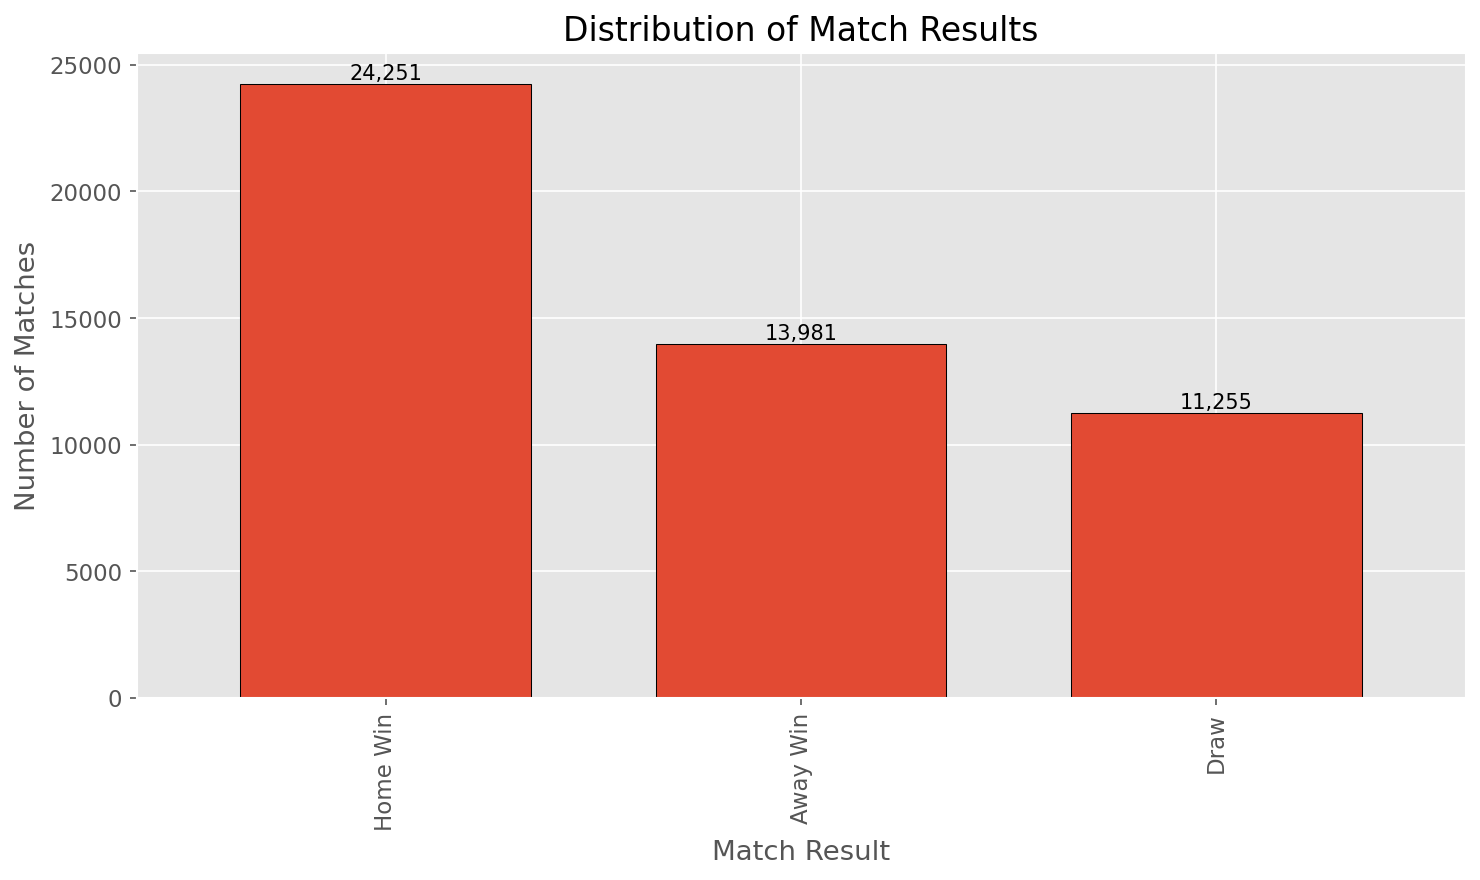

In [16]:
ax = result_counts.plot(
    kind="bar",
    edgecolor="black",
    width=0.7
)

plt.title("Distribution of Match Results")
plt.xlabel("Match Result")
plt.ylabel("Number of Matches")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Home Advantage

In [17]:
home_win_rate = df["Home_Win"].mean() * 100

print(f"Overall Home Win Rate: {home_win_rate:.2f}%")

Overall Home Win Rate: 49.00%


In [18]:
summary = pd.DataFrame({
    "Matches":[len(df)],
    "Home Win %":[round(home_win_rate,2)]
})

summary

,Matches,Home Win %
0,49487,49.0


In [19]:
matches_per_year = df.groupby("Year").size()

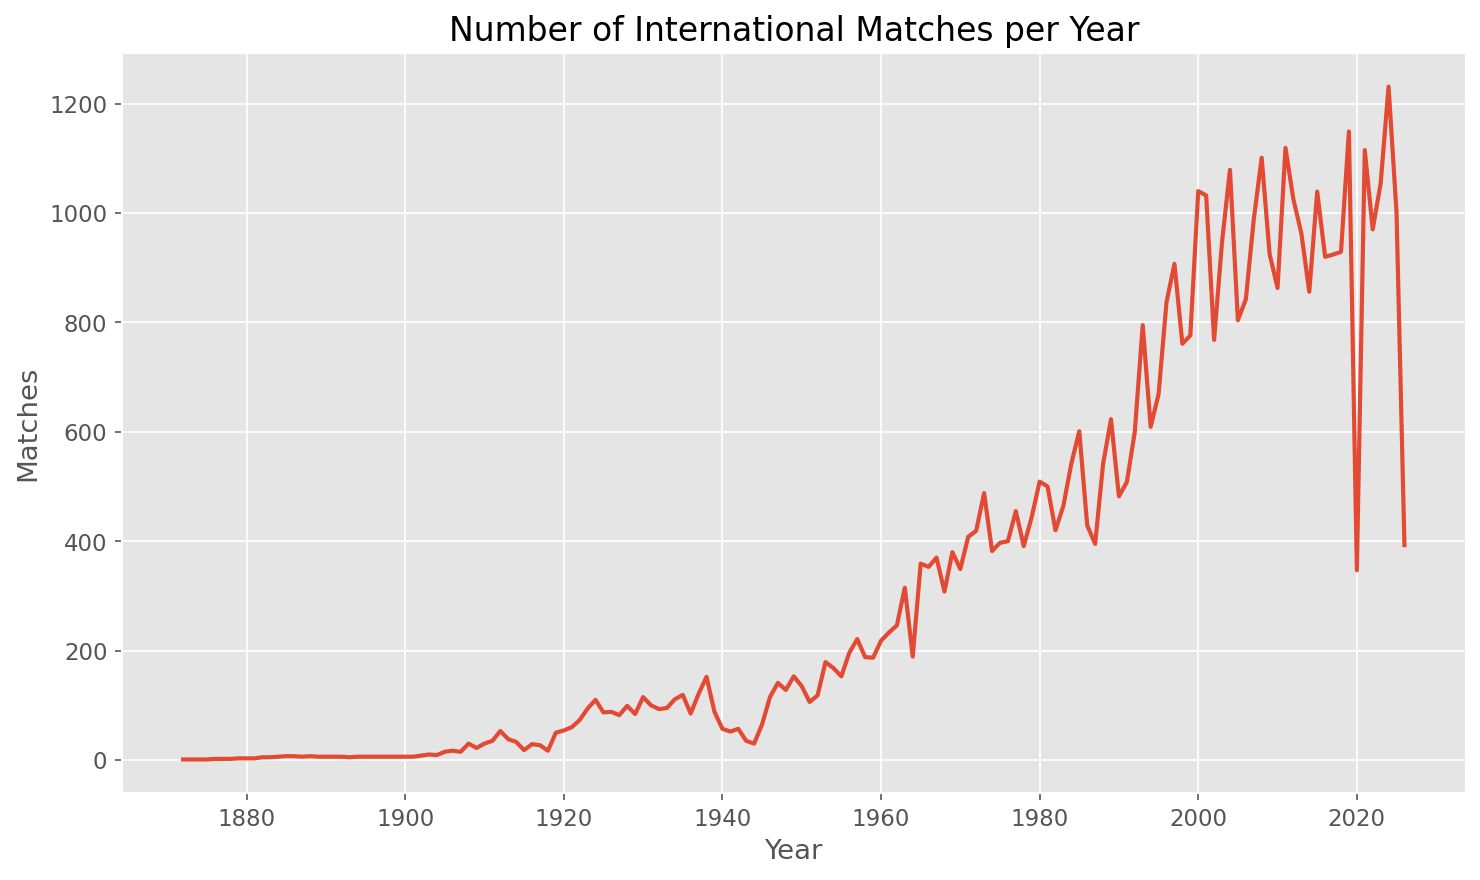

In [20]:
plt.figure()

plt.plot(
    matches_per_year.index,
    matches_per_year.values,
    linewidth=2
)

plt.title("Number of International Matches per Year")
plt.xlabel("Year")
plt.ylabel("Matches")

plt.grid(True)

plt.tight_layout()

plt.show()

### Has the home-field advantage changed over time?
### آیا مزیت میزبانی در طول زمان تغییر کرده است؟

In [21]:
home_advantage_by_era = (
    df.groupby("Era")["Home_Win"]
      .mean()
      .reset_index()
)

home_advantage_by_era["Home_Win"] *= 100

home_advantage_by_era

,Era,Home_Win
0,1872-1891,52.500000
1,1892-1911,48.400000
2,1912-1931,54.233410
3,1932-1951,52.321981
4,1952-1971,50.836902
5,1972-1991,48.216377
6,1992-2011,49.015004
7,2012-2031,47.883883


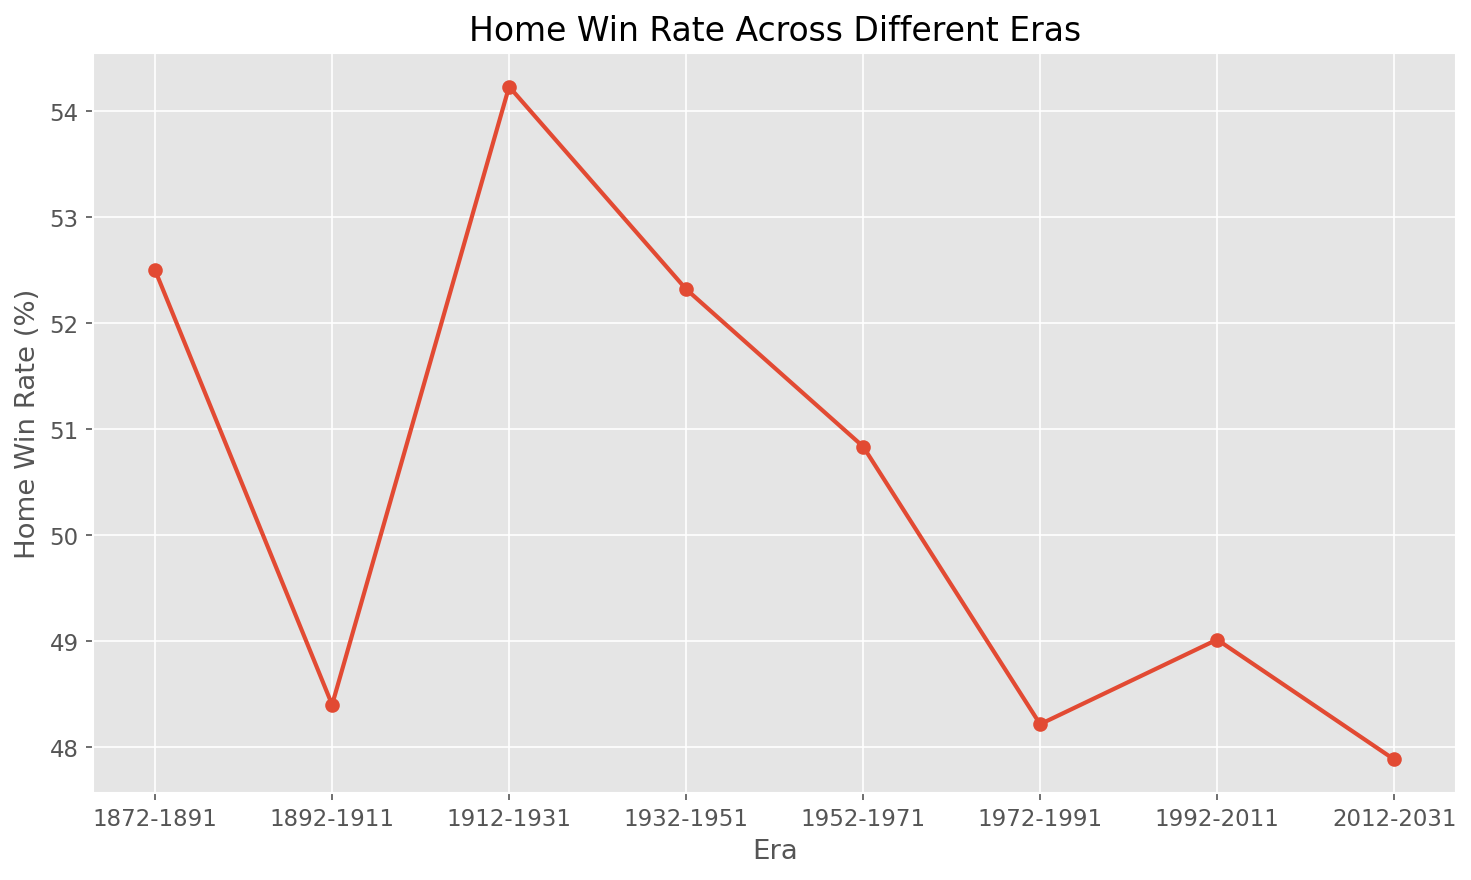

In [22]:
plt.figure(figsize=(10,6))

plt.plot(
    home_advantage_by_era["Era"].astype(str),
    home_advantage_by_era["Home_Win"],
    marker="o",
    linewidth=2
)

plt.title("Home Win Rate Across Different Eras")
plt.xlabel("Era")
plt.ylabel("Home Win Rate (%)")

plt.grid(True)

plt.tight_layout()

plt.show()

In [23]:
match_type_advantage = (
    df.groupby("Match_Type")["Home_Win"]
      .mean()
      .reset_index()
)

match_type_advantage["Home_Win"] *= 100

match_type_advantage

,Match_Type,Home_Win
0,Friendly,47.313465
1,Official,50.004823


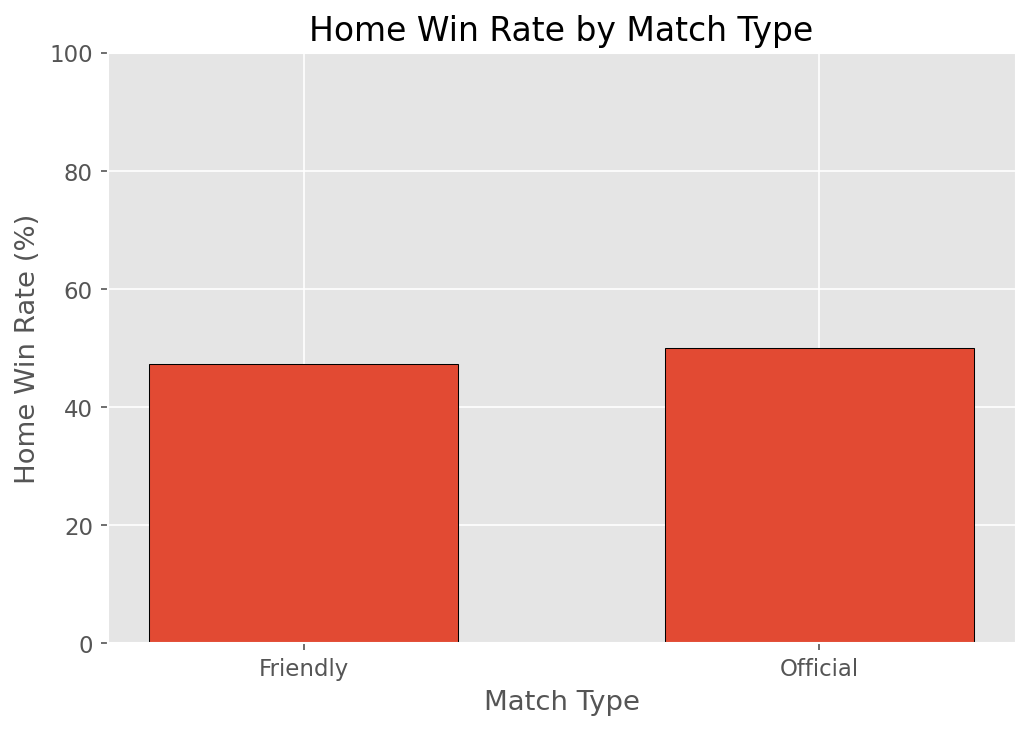

In [24]:
plt.figure(figsize=(7,5))

plt.bar(
    match_type_advantage["Match_Type"],
    match_type_advantage["Home_Win"],
    edgecolor="black",
    width=0.6
)

plt.title("Home Win Rate by Match Type")
plt.xlabel("Match Type")
plt.ylabel("Home Win Rate (%)")

plt.ylim(0, 100)

plt.tight_layout()

plt.show()

### اثر زمین بی‌طرف (Neutral)

In [25]:
neutral_advantage = (
    df.groupby("Neutral")["Home_Win"]
      .mean()
      .reset_index()
)

neutral_advantage["Home_Win"] *= 100

neutral_advantage

,Neutral,Home_Win
0,0,50.748116
1,1,44.177013


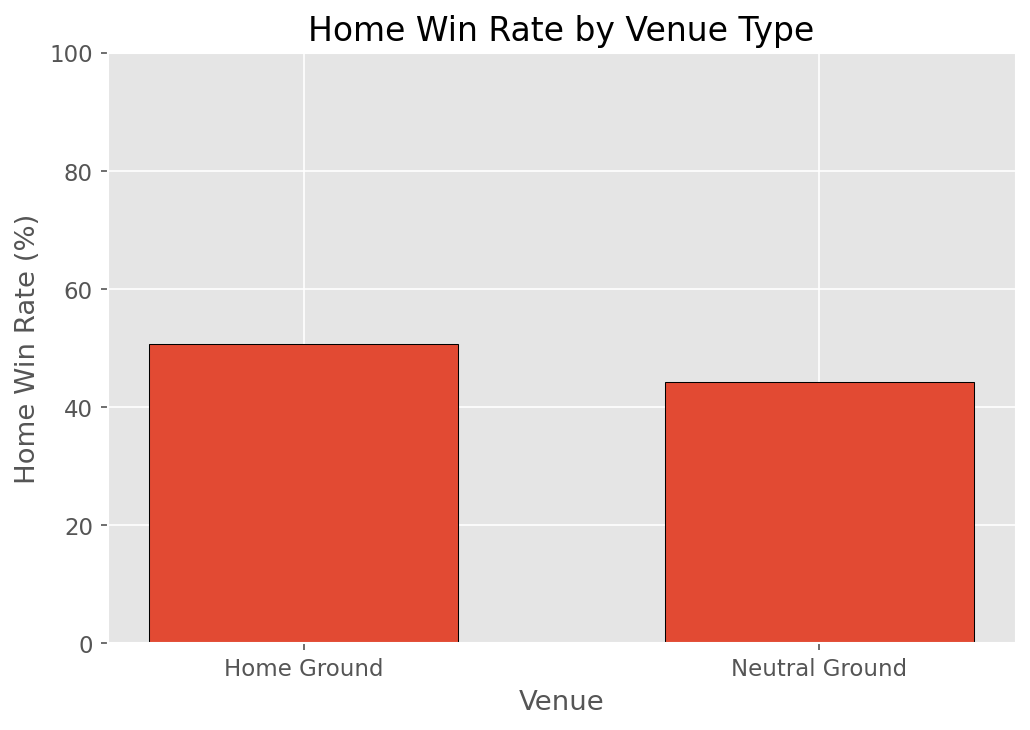

In [26]:
plt.figure(figsize=(7,5))

plt.bar(
    ["Home Ground", "Neutral Ground"],
    neutral_advantage["Home_Win"],
    edgecolor="black",
    width=0.6
)

plt.title("Home Win Rate by Venue Type")
plt.xlabel("Venue")
plt.ylabel("Home Win Rate (%)")

plt.ylim(0, 100)

plt.tight_layout()

plt.show()

In [29]:
df["Goal_Diff"].describe()

count    49487.000000
mean         0.575444
std          2.415429
min        -21.000000
25%         -1.000000
50%          0.000000
75%          2.000000
max         31.000000
Name: Goal_Diff, dtype: float64

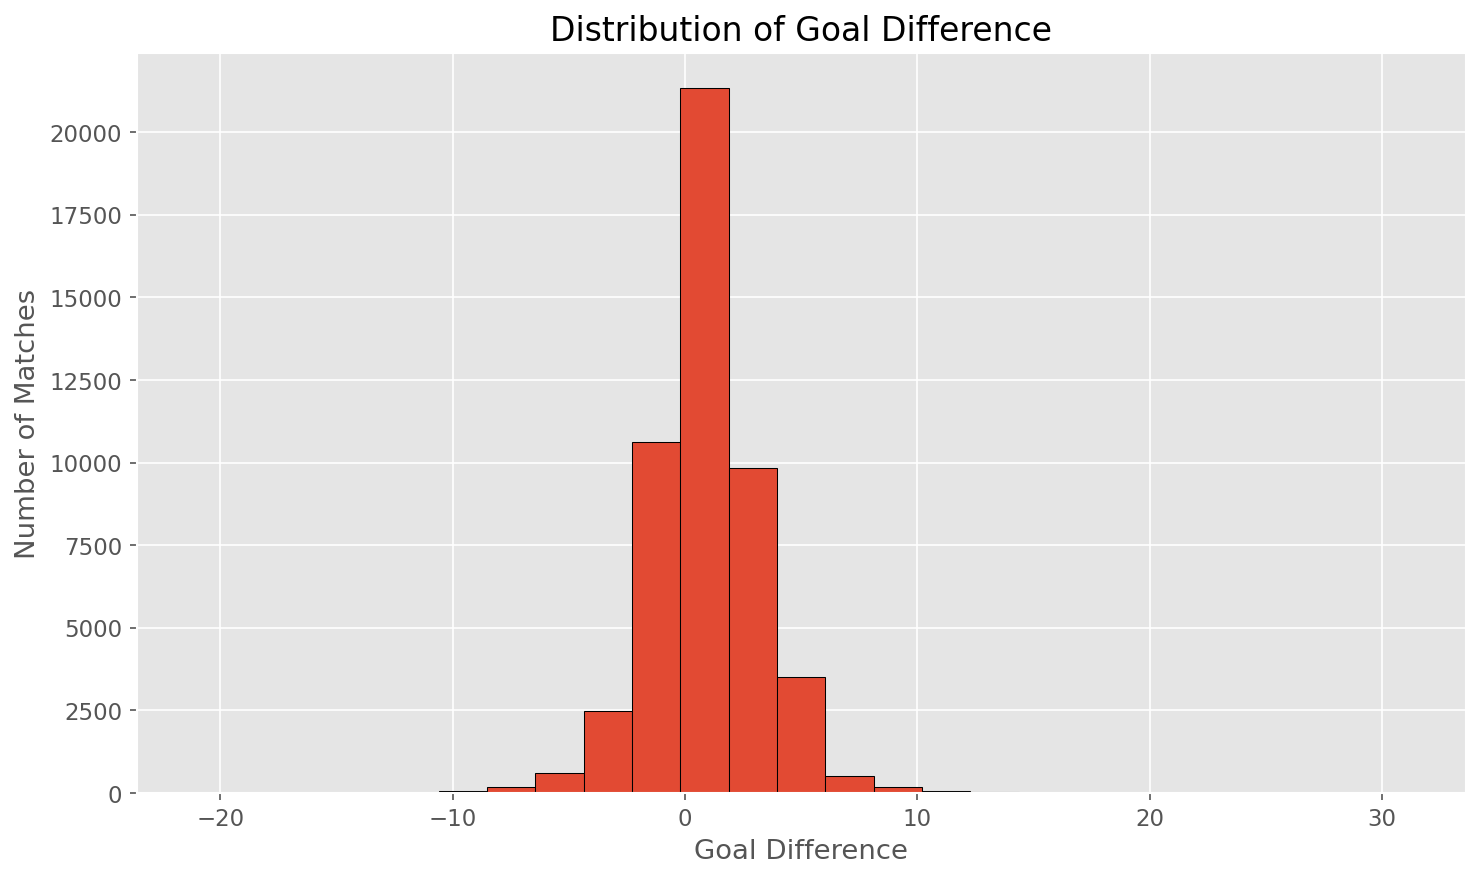

In [30]:
plt.figure(figsize=(10,6))

plt.hist(
    df["Goal_Diff"],
    bins=25,
    edgecolor="black"
)

plt.title("Distribution of Goal Difference")
plt.xlabel("Goal Difference")
plt.ylabel("Number of Matches")

plt.tight_layout()

plt.show()